In [1]:
import pandas as pd
import numpy as np
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import traceback
from greedy_auto_time_start_1 import Point

### Data preprocessing for experiments

In [2]:
CREW_MEMBERS = 3
MAX_WORK_HOURS = 12

#### Define depot points

In [3]:
depots = pd.read_csv('synthetic_data_kyiv_varash/general.csv')

In [4]:
kyiv = depots[depots['city_name'] == 'Kyiv'].iloc[0]
kyiv_depot = Point("DEPOT", kyiv['depot_lan'], kyiv['depot_lot'], "DEPOT")

In [5]:
varash = depots[depots['city_name'] == 'Varash'].iloc[0]
varash_depot = Point("DEPOT", varash['depot_lan'], varash['depot_lot'], "DEPOT")

In [6]:
depots_simple = pd.read_csv('synthetic_data_ternopil_dubno/general.csv')

In [7]:
ternopil = depots_simple[depots_simple['city_name'] == 'Ternopil'].iloc[0]
ternopil_depot = Point("DEPOT", ternopil['depot_lan'], ternopil['depot_lot'], "DEPOT")

In [8]:
dubno = depots_simple[depots_simple['city_name'] == 'Dubno'].iloc[0]
dubno_depot = Point("DEPOT", dubno['depot_lan'], dubno['depot_lot'], "DEPOT")

#### Define the list of points to be serviced

In [9]:
kyiv_small = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_15.csv')
kyiv_small_1 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_03.csv')
kyiv_meduim_1 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_22.csv')
kyiv_meduim_2 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_11.csv')
kyiv_meduim_3 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_05.csv')
kyiv_meduim_4 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_12.csv')
kyiv_meduim_5 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_25.csv')
kyiv_gross_1 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_02.csv')
kyiv_gross_2 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_23.csv')
kyiv_gross_3 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_19.csv')

In [10]:
varash_small = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_15.csv')
varash_small_1 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_23.csv')
varash_medium_1 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_10.csv')
varash_medium_2 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_21.csv')
varash_medium_3 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_09.csv')
varash_medium_4 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_24.csv')
varash_medium_5 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_12.csv')
varash_gross_1 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_06.csv')
varash_gross_2 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_02.csv')
varash_gross_3 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_25.csv')

In [11]:
ternopil_small = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_07.csv')
ternopil_small_1 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_25.csv')
ternopil_medium_1 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_22.csv')
ternopil_medium_2 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_14.csv')
ternopil_medium_3 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_23.csv')
ternopil_medium_4 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_24.csv')
ternopil_medium_5 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_13.csv')
ternopil_groos = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_01.csv')
ternopil_groos_2 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_02.csv')
ternopil_groos_3 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_15.csv')

In [12]:
dubno_small = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_01.csv')
dubno_small_1 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_21.csv')
dubno_medium_1 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_22.csv')
dubno_medium_2 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_09.csv')
dubno_medium_3 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_17.csv')
dubno_medium_4 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_16.csv')
dubno_medium_5 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_14.csv')
dubno_gross = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_12.csv')
dubno_gross_2 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_11.csv')
dubno_gross_3 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_07.csv')

In [13]:
def format_points(df):
    '''
    function to convert the data into Point class objects
    '''
    df = df.copy()
    df["point_id"] = df["point_id"].astype(str)
    points = []

    for _, row in df.iterrows():
        tw_start = str(row["tw_start"]).strip() if pd.notna(row["tw_start"]) else None
        tw_end = str(row["tw_end"]).strip() if pd.notna(row["tw_end"]) else None

        point_obj = Point(
            str(row["point_id"]),
            row["lan"],
            row["lot"],
            row["point_type"],
            tw_start,
            tw_end
        )

        points.append(point_obj)

    return points

In [14]:
kyiv_s_p = format_points(kyiv_small)
kyiv_s_1_p = format_points(kyiv_small_1)
kyiv_m_1_p = format_points(kyiv_meduim_1)
kyiv_m_2_p = format_points(kyiv_meduim_2)
kyiv_m_3_p = format_points(kyiv_meduim_3)
kyiv_m_4_p = format_points(kyiv_meduim_4)
kyiv_m_5_p = format_points(kyiv_meduim_5)
kyiv_g_1_p = format_points(kyiv_gross_1)
kyiv_g_2_p = format_points(kyiv_gross_2)
kyiv_g_3_p = format_points(kyiv_gross_3)

In [15]:
varash_s_p = format_points(varash_small)
varash_s_1_p = format_points(varash_small_1)
varash_m_1_p = format_points(varash_medium_1)
varash_m_2_p = format_points(varash_medium_2)
varash_m_3_p = format_points(varash_medium_3)
varash_m_4_p = format_points(varash_medium_4)
varash_m_5_p = format_points(varash_medium_5)
varash_g_1_p = format_points(varash_gross_1)
varash_g_2_p = format_points(varash_gross_2)
varash_g_3_p = format_points(varash_gross_3)

In [16]:
ternopil_s_p = format_points(ternopil_small)
ternopil_s_1_p = format_points(ternopil_small_1)
ternopil_m_1_p = format_points(ternopil_medium_1)
ternopil_m_2_p = format_points(ternopil_medium_2)
ternopil_m_3_p = format_points(ternopil_medium_3)
ternopil_m_4_p = format_points(ternopil_medium_4)
ternopil_m_5_p = format_points(ternopil_medium_5)
ternopil_g_p= format_points(ternopil_groos)
ternopil_g_2_p = format_points(ternopil_groos_2)
ternopil_g_3_p= format_points(ternopil_groos_3)

In [17]:
dubno_s_p = format_points(dubno_small)
dubno_s_1_p = format_points(dubno_small_1)
dubno_m_1_p = format_points(dubno_medium_1)
dubno_m_2_p = format_points(dubno_medium_2)
dubno_m_3_p = format_points(dubno_medium_3)
dubno_m_4_p = format_points(dubno_medium_4)
dubno_m_5_p = format_points(dubno_medium_5)
dubno_g_p = format_points(dubno_gross)
dubno_g_2_p = format_points(dubno_gross_2)
dubno_g_3_p = format_points(dubno_gross_3)

#### Define the params for points

In [18]:
def set_params(crew, crew_members, max_hours_work):
    result = dict()
    result['max_crews'] = crew
    result['max_workers'] =  crew*crew_members
    result['workers_per_crew'] =  crew_members
    result['max_route_duration_min'] = max_hours_work * 60
    return result

In [19]:
params_varash = set_params(varash['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)
params_kyiv = set_params(kyiv['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)

In [20]:
params_ternopil = set_params(ternopil['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)
params_dubno = set_params(dubno['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)

## Experiment - Start Time

In [21]:
import greedy_auto_time_start_1 as mod1
import greedy_time_simulate_1 as mod2

In [22]:
cases = [
        {
            "name": "Kyiv_small",
            "depo": kyiv_depot,
            "stops": kyiv_s_p,
            "params": params_kyiv
        },
        {
            "name": "Kyiv_small_1",
            "depo": kyiv_depot,
            "stops": kyiv_s_1_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_1",
            "depo": kyiv_depot,
            "stops": kyiv_m_1_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_2",
            "depo": kyiv_depot,
            "stops": kyiv_m_2_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_3",
            "depo": kyiv_depot,
            "stops": kyiv_m_3_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_4",
            "depo": kyiv_depot,
            "stops": kyiv_m_4_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_5",
            "depo": kyiv_depot,
            "stops": kyiv_m_5_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_gross_1",
            "depo": kyiv_depot,
            "stops": kyiv_g_1_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_gross_2",
            "depo": kyiv_depot,
            "stops": kyiv_g_2_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_gross_3",
            "depo": kyiv_depot,
            "stops": kyiv_g_3_p,
            "params": params_kyiv
        },
        {
            "name": "Varash_small",
            "depo": varash_depot,
            "stops": varash_s_p,
            "params": params_varash
        },
        {
            "name": "Varash_small_1",
            "depo": varash_depot,
            "stops": varash_s_1_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_1",
            "depo": varash_depot,
            "stops": varash_m_1_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_2",
            "depo": varash_depot,
            "stops": varash_m_2_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_3",
            "depo": varash_depot,
            "stops": varash_m_3_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_4",
            "depo": varash_depot,
            "stops": varash_m_4_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_5",
            "depo": varash_depot,
            "stops": varash_m_5_p,
            "params": params_varash
        },
        {
            "name": "Varash_gross_1",
            "depo": varash_depot,
            "stops": varash_g_1_p,
            "params": params_varash
        },
        {
            "name": "Varash_gross_2",
            "depo": varash_depot,
            "stops": varash_g_2_p,
            "params": params_varash
        },
        {
            "name": "Varash_gross_3",
            "depo": varash_depot,
            "stops": varash_g_3_p,
            "params": params_varash
        }
]

In [23]:
cases_simple = [
        {
            "name": "ternopil_small",
            "depo": ternopil_depot,
            "stops": ternopil_s_p,
            "params": params_ternopil
        },
        {
            "name": "ternopil_small_1",
            "depo": ternopil_depot,
            "stops": ternopil_s_1_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_1",
            "depo": ternopil_depot,
            "stops": ternopil_m_1_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_2",
            "depo": ternopil_depot,
            "stops": ternopil_m_2_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_3",
            "depo": ternopil_depot,
            "stops": ternopil_m_3_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_4",
            "depo": ternopil_depot,
            "stops": ternopil_m_4_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_5",
            "depo": ternopil_depot,
            "stops": ternopil_m_5_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_gross_1",
            "depo": ternopil_depot,
            "stops": ternopil_g_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_gross_2",
            "depo": ternopil_depot,
            "stops": ternopil_g_2_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_gross_3",
            "depo": ternopil_depot,
            "stops": ternopil_g_3_p,
            "params": params_ternopil
        },
        {
            "name": "dubno_small",
            "depo": dubno_depot,
            "stops": dubno_s_p,
            "params": params_dubno
        },
        {
            "name": "dubno_small_1",
            "depo": dubno_depot,
            "stops": dubno_s_1_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_1",
            "depo": dubno_depot,
            "stops": dubno_m_1_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_2",
            "depo": dubno_depot,
            "stops": dubno_m_2_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_3",
            "depo": dubno_depot,
            "stops": dubno_m_3_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_4",
            "depo": dubno_depot,
            "stops": dubno_m_4_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_5",
            "depo": dubno_depot,
            "stops": dubno_m_5_p,
            "params": params_dubno
        },
        {
            "name": "dubno_gross_1",
            "depo": dubno_depot,
            "stops": dubno_g_p,
            "params": params_dubno
        },
        {
            "name": "dubno_gross_2",
            "depo": dubno_depot,
            "stops": dubno_g_2_p,
            "params": params_dubno
        },
        {
            "name": "dubno_gross_3",
            "depo": dubno_depot,
            "stops": dubno_g_3_p,
            "params": params_dubno
        }
]

In [24]:
def run_start_time(cases):
    results = []
    target_duration = 480 

    for case in cases:
        name = case["name"]
        p = case["params"]
        current_cache = f"cache_routes/cache_{name}.json"

        try:
            routes_a1 = mod1.plan_routes_per_day(
                case["depo"], case["stops"], name, p["max_crews"], p["max_workers"], 
                p["workers_per_crew"], p["max_route_duration_min"], 
                current_cache,
            )

            print(f"AutoTime start: Routes for {name} done, number of routes = {len(routes_a1)}", flush=True)

            for r in routes_a1:
                results.append({
                    "Dataset": name, "Module": "Math_Start",
                    "data": r})
        except Exception as e:
            print(f"Error occured for {name} - {e}", flush=True)

        try:
            routes_a2 = mod2.plan_routes_per_day(
                case["depo"], case["stops"], name, p["max_crews"], p["max_workers"], 
                p["workers_per_crew"], p["max_route_duration_min"], 
                current_cache, "08:00", "10:00", 10, target_duration
            )

            print(f"Simulate Time start: Routes for {name} done, number of routes = {len(routes_a2)}", flush=True)

            for r in routes_a2:
                results.append({
                    "Dataset": name, "Module": "Simulate", 
                    "data": r
                })
        except Exception as e:
            print(f"[mod2] start failed: {type(e).__name__}: {e}")
            print(f"Error occured for {name} - {e}", flush=True)
            traceback.print_exc()

    return pd.DataFrame(results)

In [25]:
results = run_start_time(cases)

AutoTime start: Routes for Kyiv_small done, number of routes = 17
Simulate Time start: Routes for Kyiv_small done, number of routes = 15
AutoTime start: Routes for Kyiv_small_1 done, number of routes = 15
Simulate Time start: Routes for Kyiv_small_1 done, number of routes = 13
AutoTime start: Routes for Kyiv_medium_1 done, number of routes = 17
Simulate Time start: Routes for Kyiv_medium_1 done, number of routes = 16
AutoTime start: Routes for Kyiv_medium_2 done, number of routes = 19
Simulate Time start: Routes for Kyiv_medium_2 done, number of routes = 16
AutoTime start: Routes for Kyiv_medium_3 done, number of routes = 18
Simulate Time start: Routes for Kyiv_medium_3 done, number of routes = 17
AutoTime start: Routes for Kyiv_medium_4 done, number of routes = 20
Simulate Time start: Routes for Kyiv_medium_4 done, number of routes = 18
AutoTime start: Routes for Kyiv_medium_5 done, number of routes = 15
Simulate Time start: Routes for Kyiv_medium_5 done, number of routes = 14
AutoTim

In [26]:
results_simple = run_start_time(cases_simple)

AutoTime start: Routes for ternopil_small done, number of routes = 6
Simulate Time start: Routes for ternopil_small done, number of routes = 5
AutoTime start: Routes for ternopil_small_1 done, number of routes = 4
Simulate Time start: Routes for ternopil_small_1 done, number of routes = 3
AutoTime start: Routes for ternopil_medium_1 done, number of routes = 6
Simulate Time start: Routes for ternopil_medium_1 done, number of routes = 5
AutoTime start: Routes for ternopil_medium_2 done, number of routes = 6
Simulate Time start: Routes for ternopil_medium_2 done, number of routes = 6
AutoTime start: Routes for ternopil_medium_3 done, number of routes = 6
Simulate Time start: Routes for ternopil_medium_3 done, number of routes = 6
AutoTime start: Routes for ternopil_medium_4 done, number of routes = 7
Simulate Time start: Routes for ternopil_medium_4 done, number of routes = 6
AutoTime start: Routes for ternopil_medium_5 done, number of routes = 6
Simulate Time start: Routes for ternopil_m

### Visualization of the results 

In [27]:
def conver_results(results):
    df = results.copy()

    df["Crew"] = df["data"].apply(lambda r: r.crew_id)
    df["Duration_Min"] = df["data"].apply(lambda r: r.end_time - r.start_time)
    df["KM"] = df["data"].apply(lambda r: r.distance_km)

    df_compare = df[df["Module"].isin(["Math_Start", "Simulate"])].copy()

    dataset_summary = (
        df_compare
        .groupby(["Dataset", "Module"])
        .agg(
            routes_count=("Crew", "count"),
            total_duration=("Duration_Min", "sum"),
            total_km=("KM", "sum"),
            max_duration=("Duration_Min", "max"),
        )
        .reset_index()
    )

    dataset_compare = dataset_summary.pivot(
        index="Dataset",
        columns="Module",
        values=["routes_count", "total_duration", "total_km", "max_duration"]
    )

    dataset_compare.columns = [
        f"{metric}_{module}" for metric, module in dataset_compare.columns
    ]

    dataset_compare = dataset_compare.reset_index()
    count_cols = [col for col in dataset_compare.columns if col.startswith("routes_count_")]
    dataset_compare[count_cols] = dataset_compare[count_cols].fillna(0).astype(int)

    display(dataset_compare.round(2))
    return dataset_compare

### Results for Kyiv and Varash

In [28]:
original_results =  conver_results(results)

,Dataset,routes_count_Math_Start,routes_count_Simulate,total_duration_Math_Start,total_duration_Simulate,total_km_Math_Start,total_km_Simulate,max_duration_Math_Start,max_duration_Simulate
0,Kyiv_gross_1,20,18,14290.87,12589.44,3107.78,2823.26,719.99,717.54
1,Kyiv_gross_2,20,20,14259.80,13964.61,3105.74,3039.79,719.94,717.03
2,Kyiv_gross_3,19,17,13478.70,11947.93,3144.62,3016.79,719.96,717.86
3,Kyiv_medium_1,17,16,11949.65,11087.85,3058.86,2941.94,719.98,716.94
4,Kyiv_medium_2,19,16,13367.13,11180.32,2969.65,2588.26,719.47,717.21
5,Kyiv_medium_3,18,17,12813.59,11756.86,2999.96,2882.67,719.54,717.44
6,Kyiv_medium_4,20,18,14279.30,12607.71,3090.21,2847.50,719.92,718.20
7,Kyiv_medium_5,15,14,10634.34,9704.34,2813.00,2470.30,719.72,716.80
8,Kyiv_small,17,15,12060.06,10505.34,2761.16,2592.32,719.96,717.51
9,Kyiv_small_1,15,13,10589.07,9080.63,2443.38,2314.06,719.65,716.94


### Results for Ternopil and Dubno

In [29]:
smaller_results = conver_results(results_simple)

,Dataset,routes_count_Math_Start,routes_count_Simulate,total_duration_Math_Start,total_duration_Simulate,total_km_Math_Start,total_km_Simulate,max_duration_Math_Start,max_duration_Simulate
0,dubno_gross_1,2,2,929.87,967.19,143.85,143.18,597.93,591.76
1,dubno_gross_2,1,2,574.73,866.28,121.04,141.86,574.73,539.10
2,dubno_gross_3,2,2,889.80,949.80,140.56,140.56,605.52,605.52
3,dubno_medium_1,2,2,515.70,615.70,109.88,113.72,440.21,480.21
4,dubno_medium_2,2,2,688.99,746.54,126.45,124.83,550.28,547.83
5,dubno_medium_3,2,2,691.43,751.43,115.94,115.94,556.42,556.42
6,dubno_medium_4,2,2,589.78,624.34,99.04,99.04,510.20,484.77
7,dubno_medium_5,1,1,386.14,403.49,118.32,107.99,386.14,403.49
8,dubno_small,1,1,490.28,480.28,114.64,116.70,490.28,480.28
9,dubno_small_1,1,1,310.61,370.61,73.59,73.59,310.61,370.61


In [30]:
def plot_metric_by_city(
    dataset_compare,
    metric_math,
    metric_sim,
    ylabel,
    title_prefix,
    city,
    color_math="#FFD700",
    color_sim="#A4C639",
    width=0.35,
    figsize=(12, 6),
    rotate_xticks=45):

    data = dataset_compare[dataset_compare["Dataset"].str.startswith(city)].copy()
    data = data.sort_values("Dataset")

    x = np.arange(len(data))
    
    fig, ax = plt.subplots(figsize=figsize)
    
    ax.bar(x - width/2, data[metric_math], width, label="Math_Start", color=color_math)
    ax.bar(x + width/2, data[metric_sim], width, label="Simulate", color=color_sim)

    ax.set_xticks(x)
    ax.set_xticklabels(data["Dataset"], rotation=rotate_xticks, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title_prefix} ({city})")
    ax.legend()

    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()

In [31]:
def build_win_table(dataset_compare, metrics):
    rows = []

    for metric in metrics:
        math_col = f"{metric}_Math_Start"
        sim_col = f"{metric}_Simulate"

        math_better = (dataset_compare[math_col] < dataset_compare[sim_col]).sum()
        sim_better = (dataset_compare[sim_col] < dataset_compare[math_col]).sum()
        ties = (dataset_compare[math_col] == dataset_compare[sim_col]).sum()

        rows.append({
            "Metric": metric,
            "Math_Start_better": math_better,
            "Simulate_better": sim_better,
            "Both_equal": ties
        })

    return pd.DataFrame(rows)

### General comparison

In [32]:
all_results_compare = pd.concat([original_results, smaller_results], ignore_index=True)
win_table = build_win_table(
    all_results_compare,
    ["routes_count", "total_duration", "total_km", "max_duration"]
)

display(win_table)

,Metric,Math_Start_better,Simulate_better,Both_equal
0,routes_count,1,13,26
1,total_duration,14,26,0
2,total_km,9,26,5
3,max_duration,3,34,3


In [33]:
for metric in ["routes_count", "total_duration", "total_km", "max_duration"]:
    math_col = f"{metric}_Math_Start"
    sim_col = f"{metric}_Simulate"

    all_results_compare[f"{metric}_diff_abs"] = (
        all_results_compare[sim_col] - all_results_compare[math_col]
    )

    all_results_compare[f"{metric}_diff_pct_vs_math"] = (
        (all_results_compare[sim_col] - all_results_compare[math_col])
        / all_results_compare[math_col] * 100
    )
diff_summary = all_results_compare[[
    "total_duration_diff_abs",
    "total_duration_diff_pct_vs_math",
    "total_km_diff_abs",
    "total_km_diff_pct_vs_math",
    "max_duration_diff_abs",
    "max_duration_diff_pct_vs_math"
]].agg(["mean", "median", "min", "max"])

print('Methods comparison (Simulate - Math start)')
display(diff_summary.round(2))

Methods comparison (Simulate - Math start)


,total_duration_diff_abs,total_duration_diff_pct_vs_math,total_km_diff_abs,total_km_diff_pct_vs_math,max_duration_diff_abs,max_duration_diff_pct_vs_math
mean,-402.97,-1.49,-55.29,-2.39,-4.72,-0.35
median,-39.11,-2.05,-11.23,-2.39,-2.75,-0.39
min,-2186.81,-24.38,-381.38,-15.03,-98.66,-13.76
max,291.55,50.73,60.04,17.20,60.00,19.32


In [34]:
print('Top-10 where start time based on simulations outperforms math approach (duration comparison)')
all_results_compare[[
    "Dataset",
    "total_duration_Math_Start",
    "total_duration_Simulate",
    "total_duration_diff_abs",
    "total_duration_diff_pct_vs_math"
]].sort_values("total_duration_diff_abs").head(10)

Top-10 where start time based on simulations outperforms math approach (duration comparison)


,Dataset,total_duration_Math_Start,total_duration_Simulate,total_duration_diff_abs,total_duration_diff_pct_vs_math
4,Kyiv_medium_2,13367.133333,11180.323333,-2186.810000,-16.359603
0,Kyiv_gross_1,14290.873333,12589.443333,-1701.430000,-11.905710
6,Kyiv_medium_4,14279.300000,12607.713333,-1671.586667,-11.706363
8,Kyiv_small,12060.058333,10505.335000,-1554.723333,-12.891508
2,Kyiv_gross_3,13478.705000,11947.933333,-1530.771667,-11.356964
9,Kyiv_small_1,10589.066667,9080.631667,-1508.435000,-14.245212
5,Kyiv_medium_3,12813.593333,11756.856667,-1056.736667,-8.246997
7,Kyiv_medium_5,10634.340000,9704.340000,-930.000000,-8.745254
36,ternopil_medium_4,4914.651667,4051.483333,-863.168333,-17.563164
3,Kyiv_medium_1,11949.648333,11087.853333,-861.795000,-7.211886


In [35]:
print('Top-10 where start time based on calculations outperforms simulations (duration comparison)')
all_results_compare[[
    "Dataset",
    "total_duration_Math_Start",
    "total_duration_Simulate",
    "total_duration_diff_abs",
    "total_duration_diff_pct_vs_math"
]].sort_values("total_duration_diff_abs", ascending=False).head(10)

Top-10 where start time based on calculations outperforms simulations (duration comparison)


,Dataset,total_duration_Math_Start,total_duration_Simulate,total_duration_diff_abs,total_duration_diff_pct_vs_math
21,dubno_gross_2,574.731667,866.283333,291.551667,50.728311
23,dubno_medium_1,515.701667,615.701667,100.000000,19.391056
13,Varash_medium_1,850.256667,929.075000,78.818333,9.269946
17,Varash_medium_5,1012.251667,1072.251667,60.000000,5.927380
25,dubno_medium_3,691.430000,751.430000,60.000000,8.677668
22,dubno_gross_3,889.795000,949.795000,60.000000,6.743126
29,dubno_small_1,310.613333,370.613333,60.000000,19.316621
24,dubno_medium_2,688.988333,746.540000,57.551667,8.353068
19,Varash_small_1,851.041667,900.601667,49.560000,5.823452
20,dubno_gross_1,929.873333,967.190000,37.316667,4.013091


In [36]:
print('Top-10 where start time based on simulations outperforms math approach (distance comparison)')
all_results_compare[[
    "Dataset",
    "total_km_Math_Start",
    "total_km_Simulate",
    "total_km_diff_abs",
    "total_km_diff_pct_vs_math"
]].sort_values("total_km_diff_abs").head(10)

Top-10 where start time based on simulations outperforms math approach (distance comparison)


,Dataset,total_km_Math_Start,total_km_Simulate,total_km_diff_abs,total_km_diff_pct_vs_math
4,Kyiv_medium_2,2969.6469,2588.2640,-381.3829,-12.842702
7,Kyiv_medium_5,2813.0028,2470.3004,-342.7024,-12.182796
0,Kyiv_gross_1,3107.7754,2823.2647,-284.5107,-9.154802
6,Kyiv_medium_4,3090.2107,2847.4987,-242.7120,-7.854222
8,Kyiv_small,2761.1567,2592.3169,-168.8398,-6.114821
9,Kyiv_small_1,2443.3840,2314.0639,-129.3201,-5.292664
2,Kyiv_gross_3,3144.6248,3016.7929,-127.8319,-4.065092
5,Kyiv_medium_3,2999.9583,2882.6706,-117.2877,-3.909644
3,Kyiv_medium_1,3058.8621,2941.9428,-116.9193,-3.822314
12,Varash_gross_3,483.9018,411.1759,-72.7259,-15.029062


In [37]:
print('Top-10 where start time based on calculations outperforms simulationsh (distance comparison)')
all_results_compare[[
    "Dataset",
    "total_km_Math_Start",
    "total_km_Simulate",
    "total_km_diff_abs",
    "total_km_diff_pct_vs_math"
]].sort_values("total_km_diff_abs").head(10)

Top-10 where start time based on calculations outperforms simulationsh (distance comparison)


,Dataset,total_km_Math_Start,total_km_Simulate,total_km_diff_abs,total_km_diff_pct_vs_math
4,Kyiv_medium_2,2969.6469,2588.2640,-381.3829,-12.842702
7,Kyiv_medium_5,2813.0028,2470.3004,-342.7024,-12.182796
0,Kyiv_gross_1,3107.7754,2823.2647,-284.5107,-9.154802
6,Kyiv_medium_4,3090.2107,2847.4987,-242.7120,-7.854222
8,Kyiv_small,2761.1567,2592.3169,-168.8398,-6.114821
9,Kyiv_small_1,2443.3840,2314.0639,-129.3201,-5.292664
2,Kyiv_gross_3,3144.6248,3016.7929,-127.8319,-4.065092
5,Kyiv_medium_3,2999.9583,2882.6706,-117.2877,-3.909644
3,Kyiv_medium_1,3058.8621,2941.9428,-116.9193,-3.822314
12,Varash_gross_3,483.9018,411.1759,-72.7259,-15.029062


In [46]:
def build_comparison_table(all_results_compare):
    df = all_results_compare.copy()

    def extract_city(name):
        name = str(name).lower()
        if "kyiv" in name:
            return "Kyiv"
        elif "varash" in name:
            return "Varash"
        elif "ternopil" in name:
            return "Ternopil"
        elif "dubno" in name:
            return "Dubno"
        return None

    df["City"] = df["Dataset"].apply(extract_city)
    df = df.dropna(subset=["City"])

    summary = (
        df.groupby("City")
        .agg(
            Math_Start=("total_duration_Math_Start", "mean"),
            Simulate=("total_duration_Simulate", "mean")
        )
        .reset_index()
    )

    summary["Better approach"] = summary.apply(
        lambda row: "Simulate" if row["Simulate"] < row["Math_Start"] else "Math_Start",
        axis=1
    )

    summary["Improvement, %"] = (
        abs(summary["Math_Start"] - summary["Simulate"])
        / summary[["Math_Start", "Simulate"]].max(axis=1)
        * 100
    )
    city_order = ["Kyiv", "Varash", "Ternopil", "Dubno"]
    summary["City"] = pd.Categorical(summary["City"], categories=city_order, ordered=True)
    summary = summary.sort_values("City")

    return summary.round(2)

In [47]:
start_time_city_table = build_comparison_table(all_results_compare)
display(start_time_city_table)

,City,Math_Start,Simulate,Better approach,"Improvement, %"
1,Kyiv,12772.25,11442.50,Simulate,10.41
3,Varash,1032.82,1038.13,Math_Start,0.51
2,Ternopil,4291.74,3933.45,Simulate,8.35
0,Dubno,606.73,677.57,Math_Start,10.45


#### Visualization for Kyiv and Varash

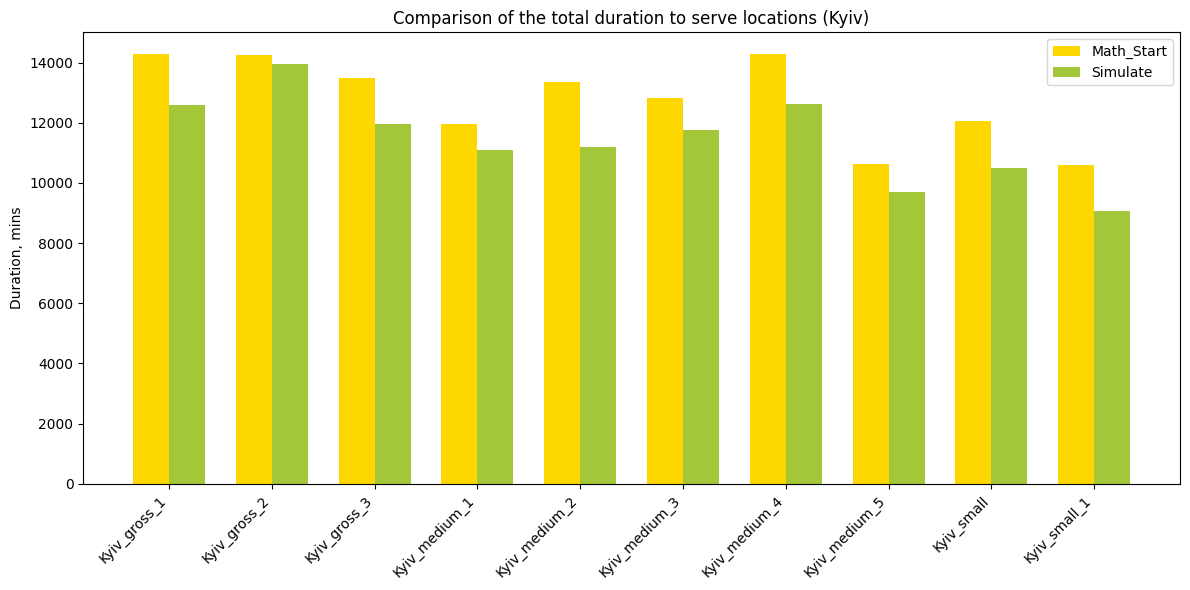

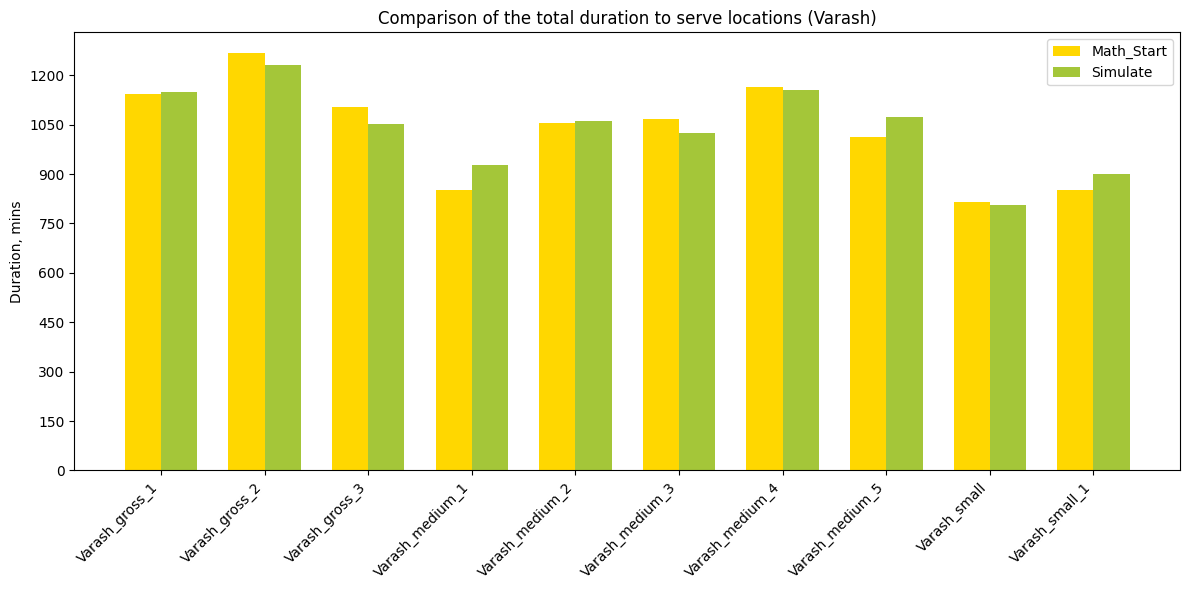

In [38]:
plot_metric_by_city(
    dataset_compare=original_results,
    metric_math="total_duration_Math_Start",
    metric_sim="total_duration_Simulate",
    ylabel="Duration, mins",
    title_prefix="Comparison of the total duration to serve locations",
    city="Kyiv"
)

plot_metric_by_city(
    dataset_compare=original_results,
    metric_math="total_duration_Math_Start",
    metric_sim="total_duration_Simulate",
    ylabel="Duration, mins",
    title_prefix="Comparison of the total duration to serve locations",
    city="Varash"
)

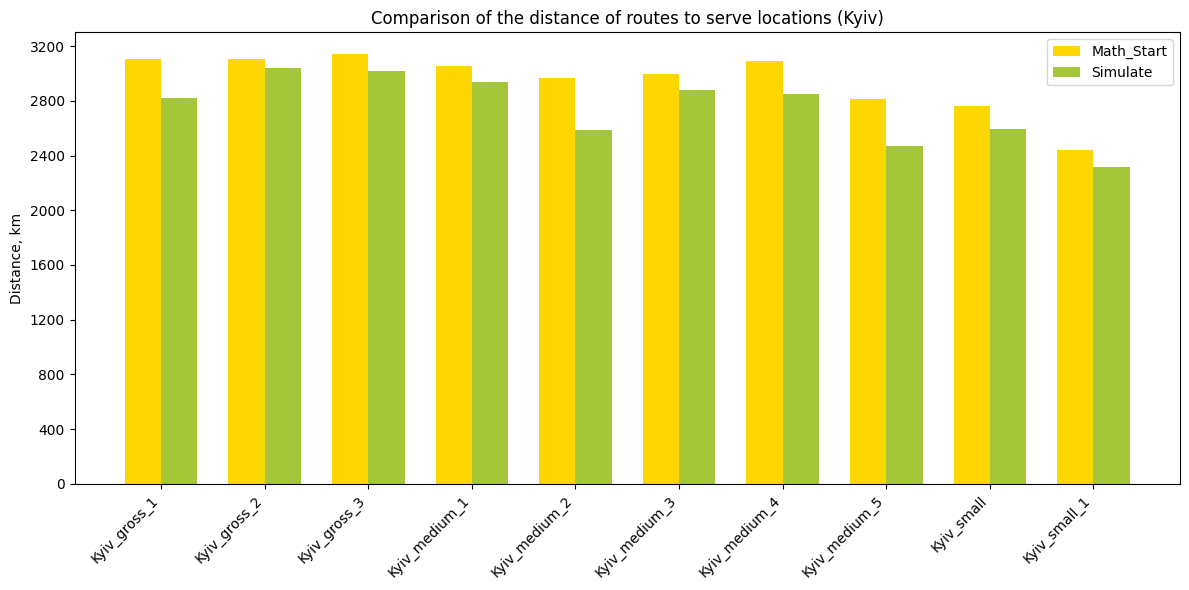

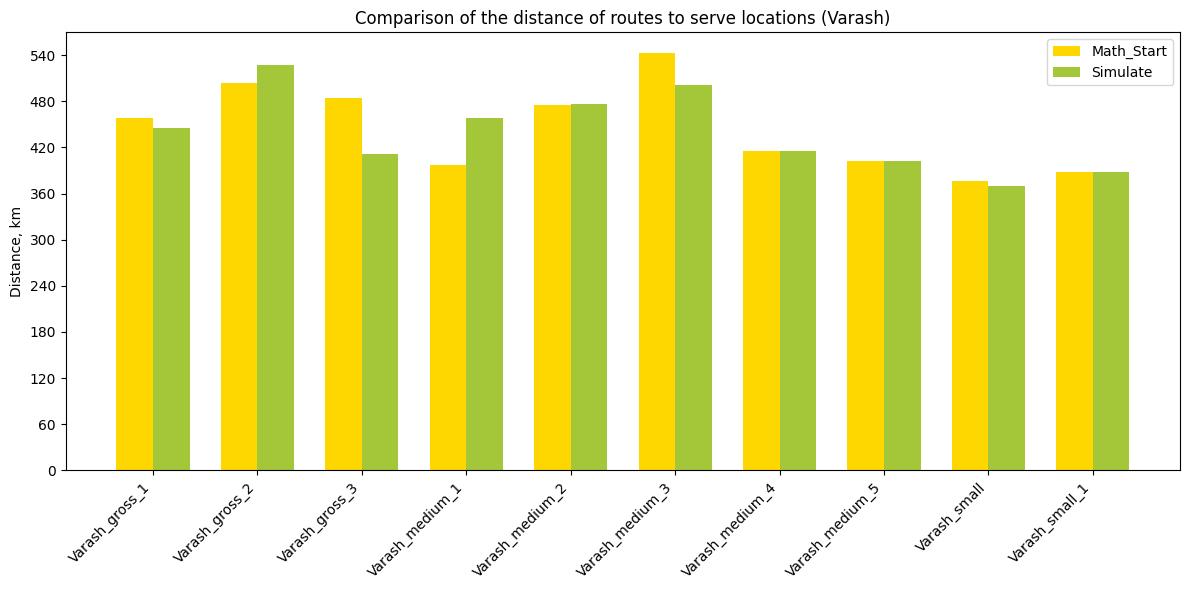

In [39]:
plot_metric_by_city(
    dataset_compare=original_results,
    metric_math="total_km_Math_Start",
    metric_sim="total_km_Simulate",
    ylabel="Distance, km",
    title_prefix="Comparison of the distance of routes to serve locations",
    city="Kyiv"
)

plot_metric_by_city(
    dataset_compare=original_results,
    metric_math="total_km_Math_Start",
    metric_sim="total_km_Simulate",
    ylabel="Distance, km",
    title_prefix="Comparison of the distance of routes to serve locations",
    city="Varash"
)

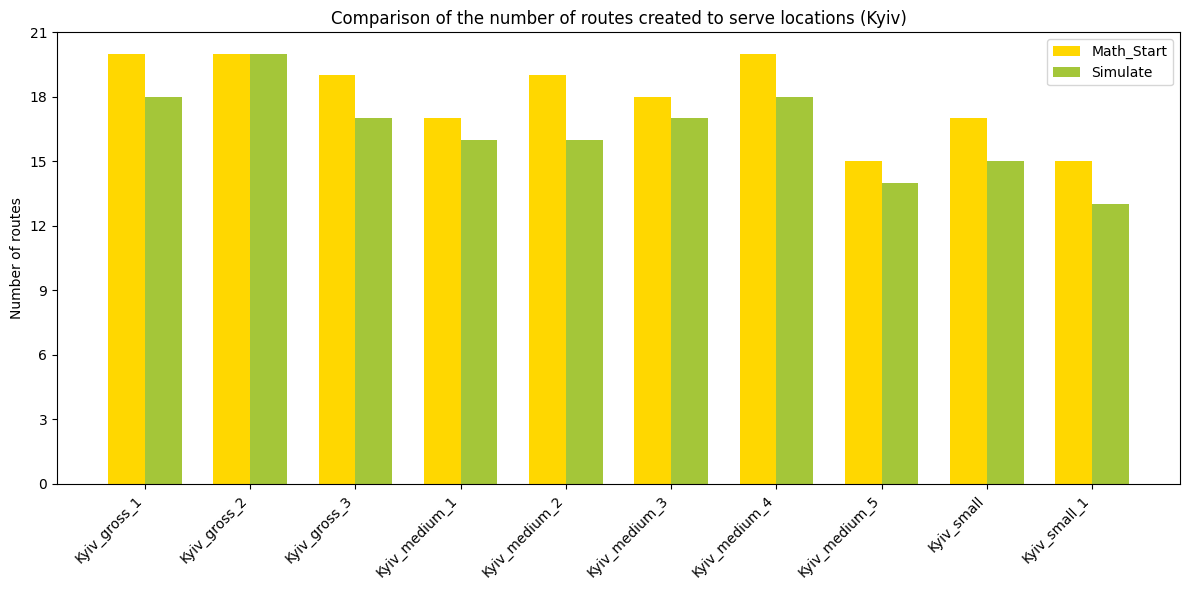

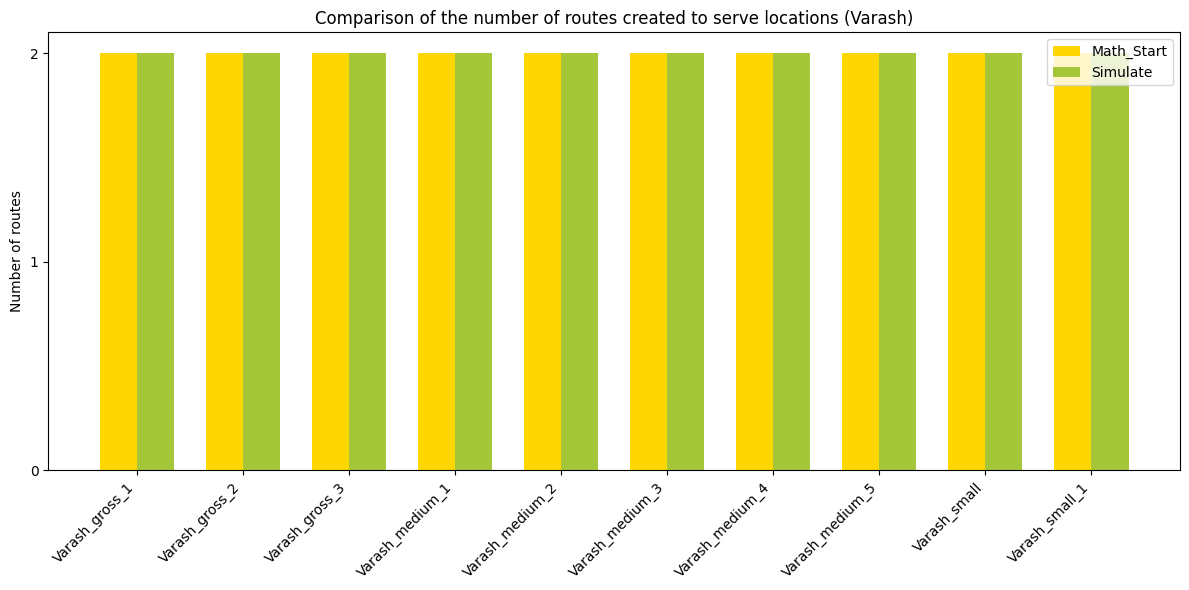

In [40]:
plot_metric_by_city(
    dataset_compare=original_results,
    metric_math="routes_count_Math_Start",
    metric_sim="routes_count_Simulate",
    ylabel="Number of routes",
    title_prefix="Comparison of the number of routes created to serve locations",
    city="Kyiv"
)

plot_metric_by_city(
    dataset_compare=original_results,
    metric_math="routes_count_Math_Start",
    metric_sim="routes_count_Simulate",
    ylabel="Number of routes",
    title_prefix="Comparison of the number of routes created to serve locations",
    city="Varash"
)

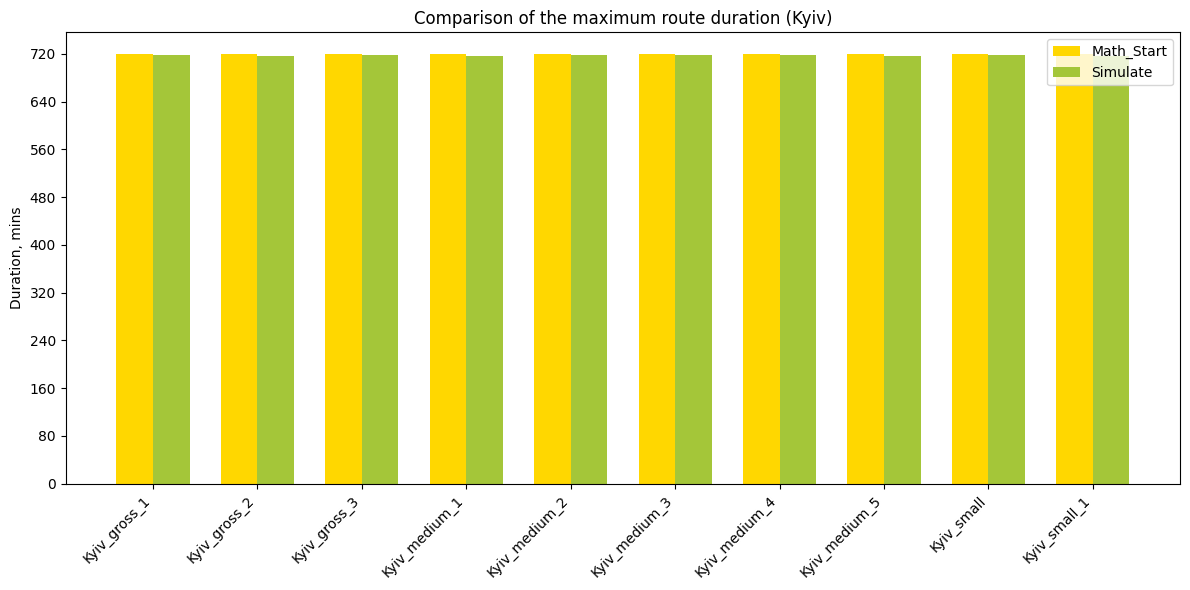

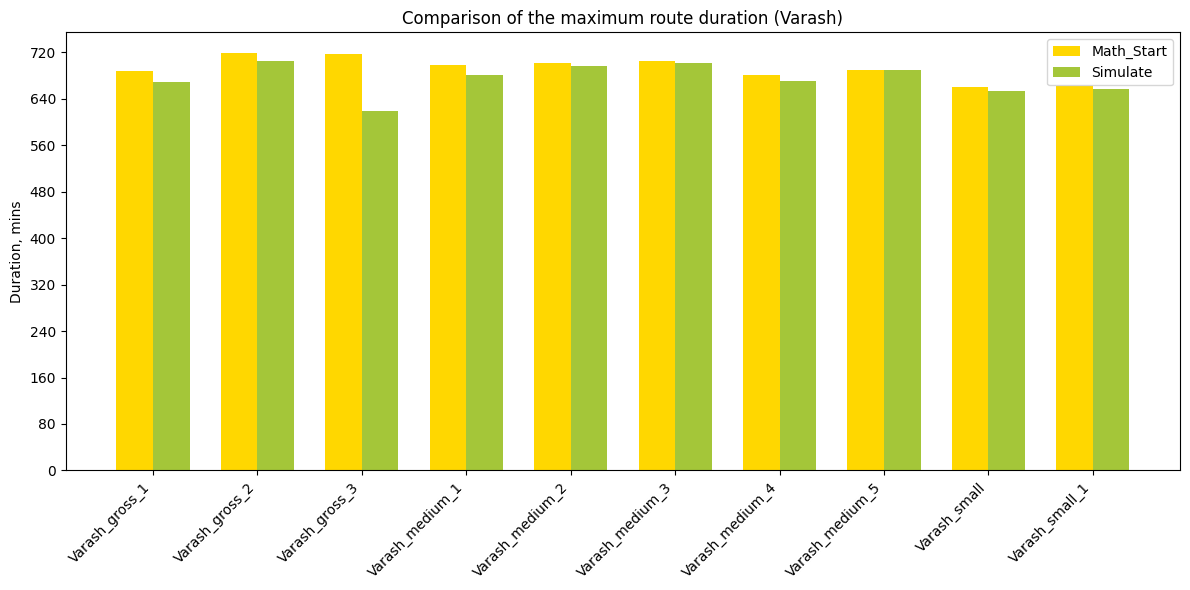

In [41]:
plot_metric_by_city(
    dataset_compare=original_results,
    metric_math="max_duration_Math_Start",
    metric_sim="max_duration_Simulate",
    ylabel="Duration, mins",
    title_prefix="Comparison of the maximum route duration",
    city="Kyiv"
)

plot_metric_by_city(
    dataset_compare=original_results,
    metric_math="max_duration_Math_Start",
    metric_sim="max_duration_Simulate",
    ylabel="Duration, mins",
    title_prefix="Comparison of the maximum route duration",
    city="Varash"
)

#### Visualization for Ternopil and Dubno

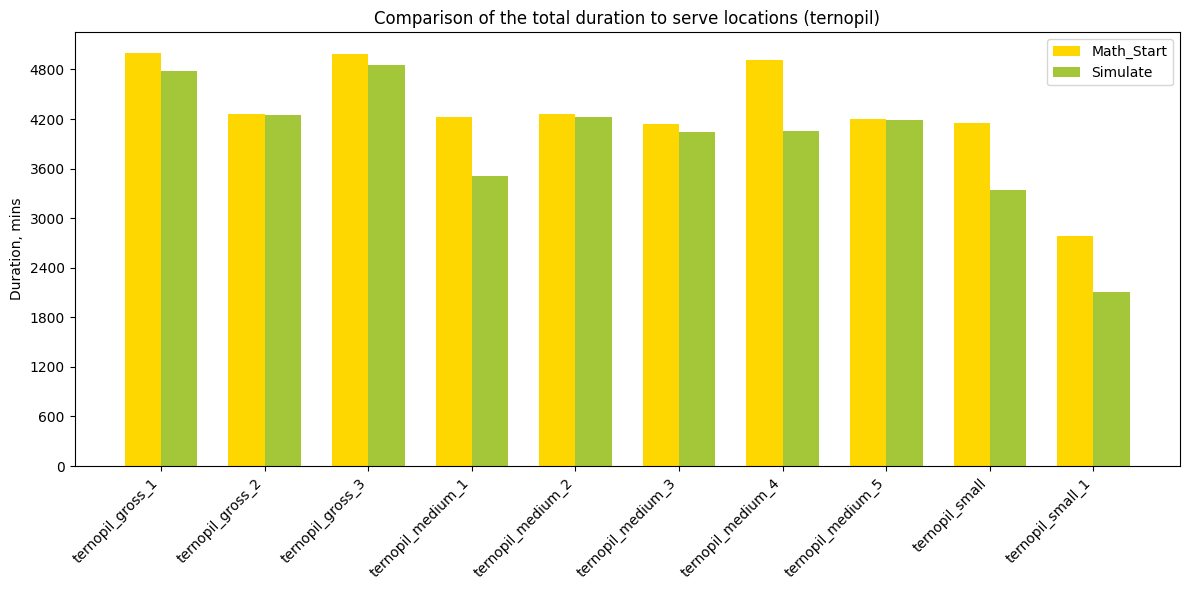

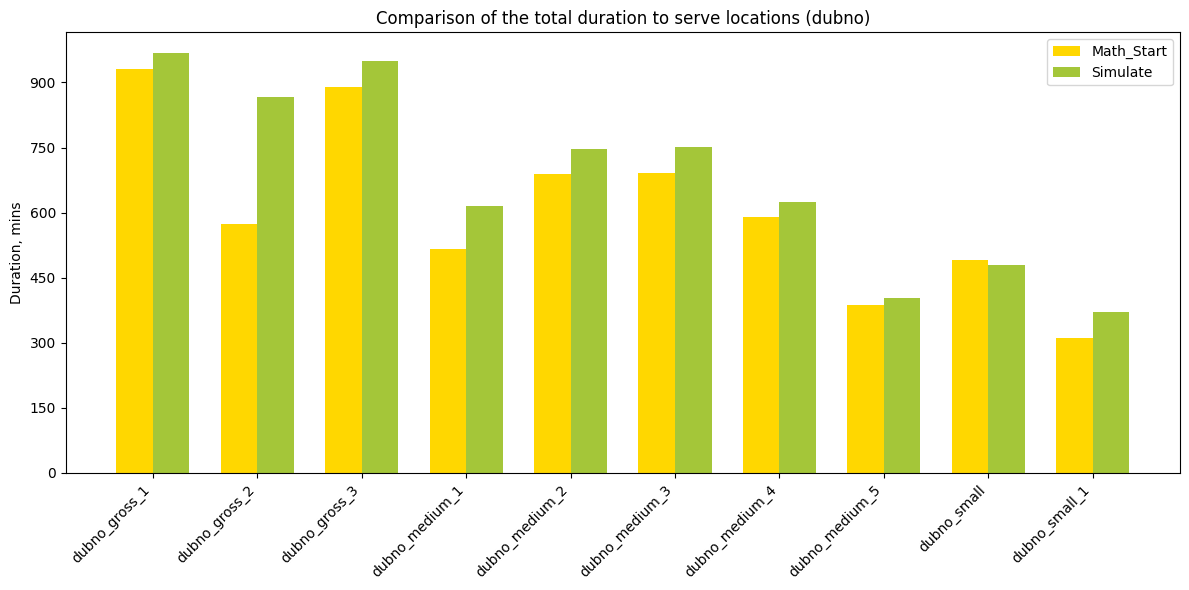

In [42]:
plot_metric_by_city(
    dataset_compare=smaller_results,
    metric_math="total_duration_Math_Start",
    metric_sim="total_duration_Simulate",
    ylabel="Duration, mins",
    title_prefix="Comparison of the total duration to serve locations",
    city="ternopil"
)

plot_metric_by_city(
    dataset_compare=smaller_results,
    metric_math="total_duration_Math_Start",
    metric_sim="total_duration_Simulate",
    ylabel="Duration, mins",
    title_prefix="Comparison of the total duration to serve locations",
    city="dubno"
)

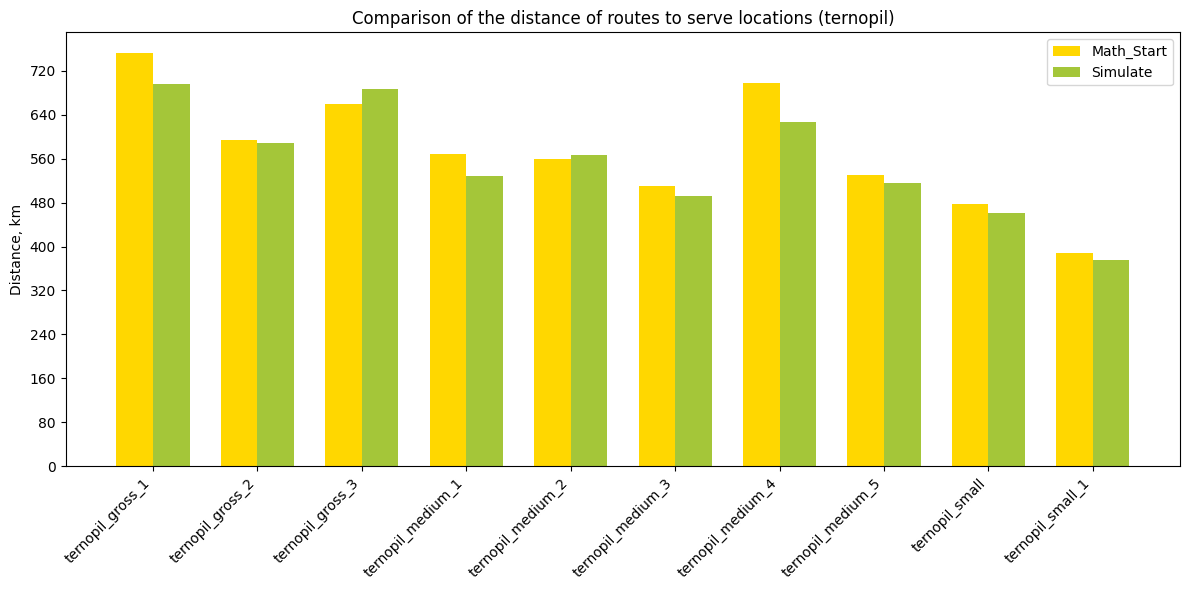

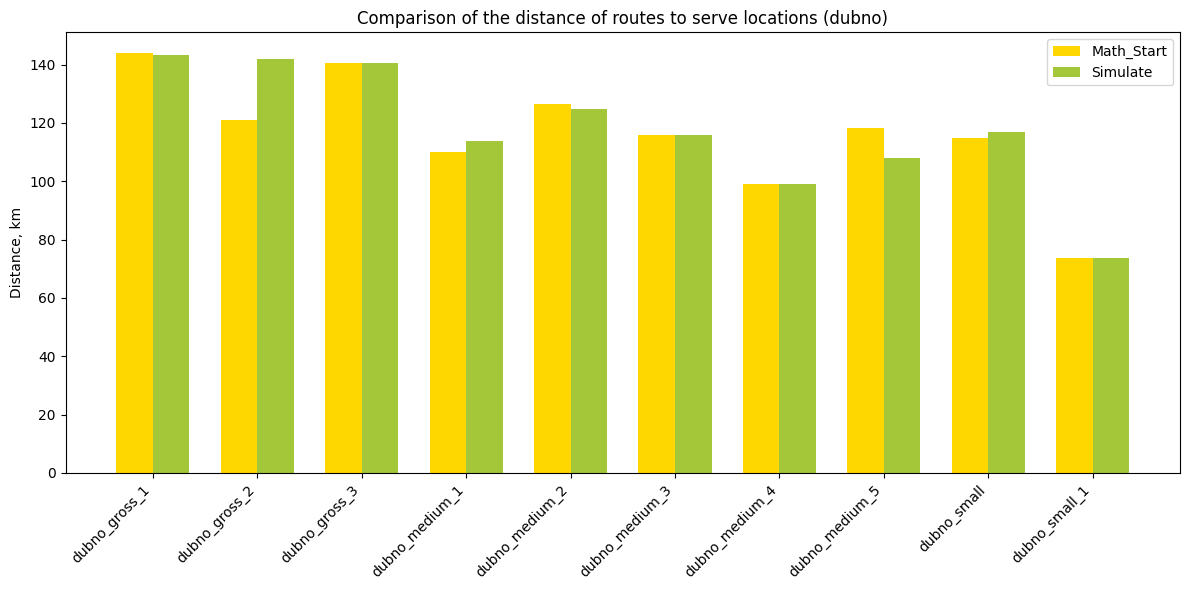

In [43]:
plot_metric_by_city(
    dataset_compare=smaller_results,
    metric_math="total_km_Math_Start",
    metric_sim="total_km_Simulate",
    ylabel="Distance, km",
    title_prefix="Comparison of the distance of routes to serve locations",
    city="ternopil"
)

plot_metric_by_city(
    dataset_compare=smaller_results,
    metric_math="total_km_Math_Start",
    metric_sim="total_km_Simulate",
    ylabel="Distance, km",
    title_prefix="Comparison of the distance of routes to serve locations",
    city="dubno"
)

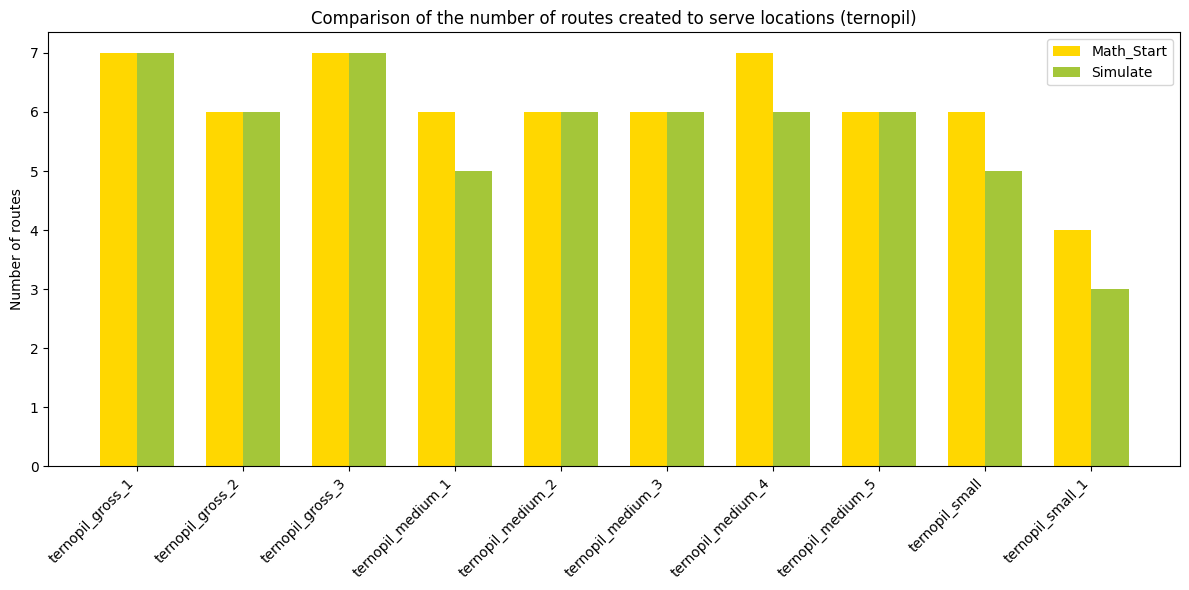

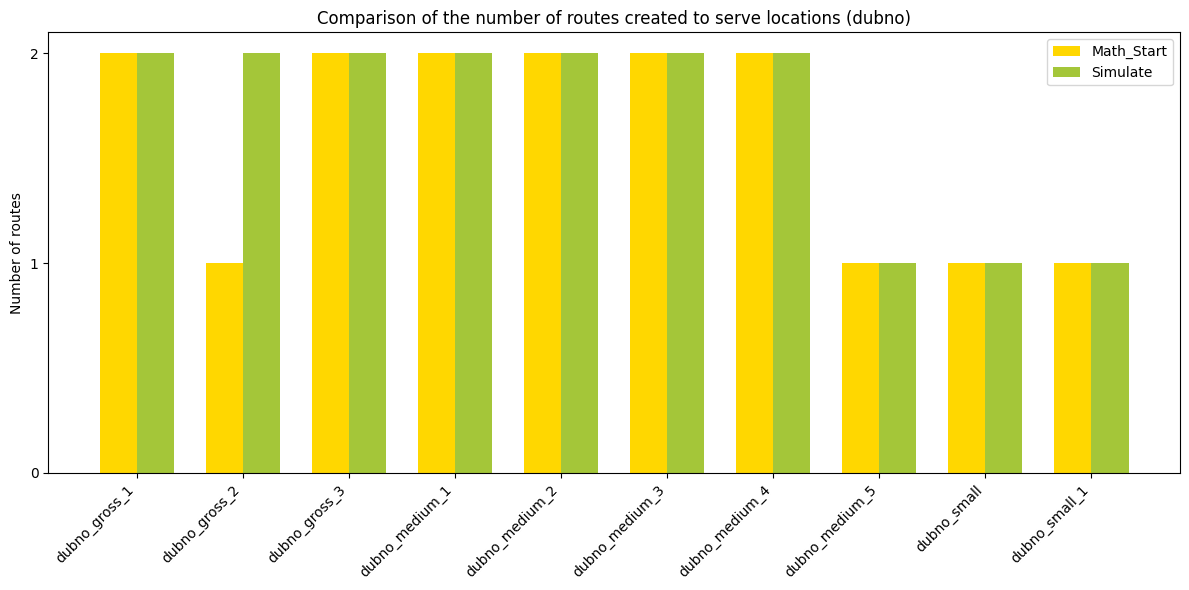

In [44]:
plot_metric_by_city(
    dataset_compare=smaller_results,
    metric_math="routes_count_Math_Start",
    metric_sim="routes_count_Simulate",
    ylabel="Number of routes",
    title_prefix="Comparison of the number of routes created to serve locations",
    city="ternopil"
)

plot_metric_by_city(
    dataset_compare=smaller_results,
    metric_math="routes_count_Math_Start",
    metric_sim="routes_count_Simulate",
    ylabel="Number of routes",
    title_prefix="Comparison of the number of routes created to serve locations",
    city="dubno"
)

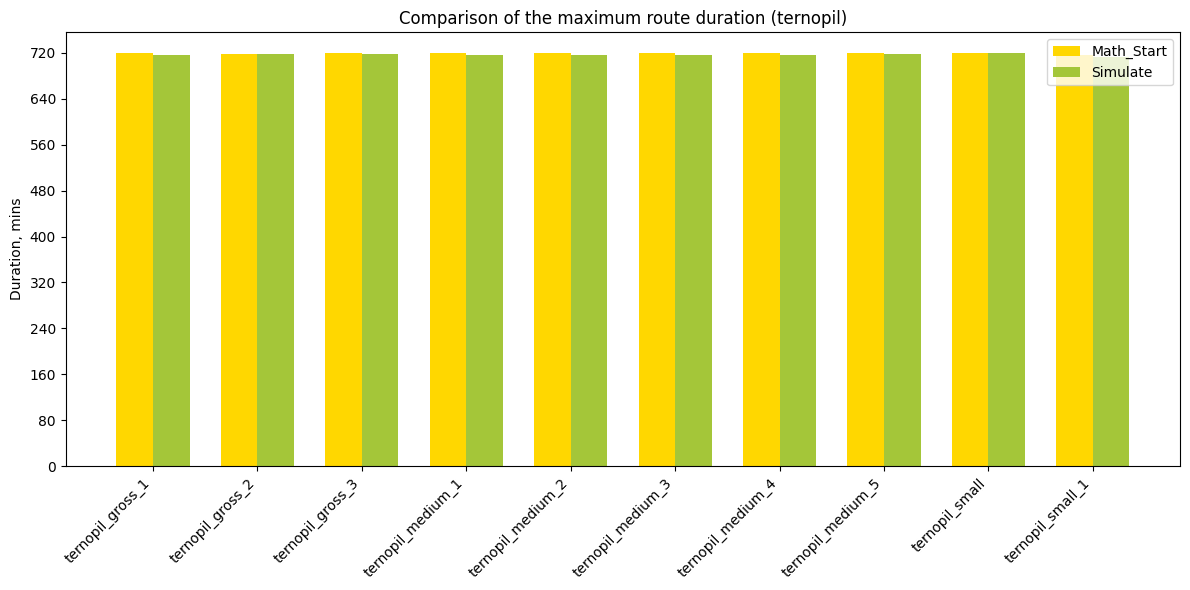

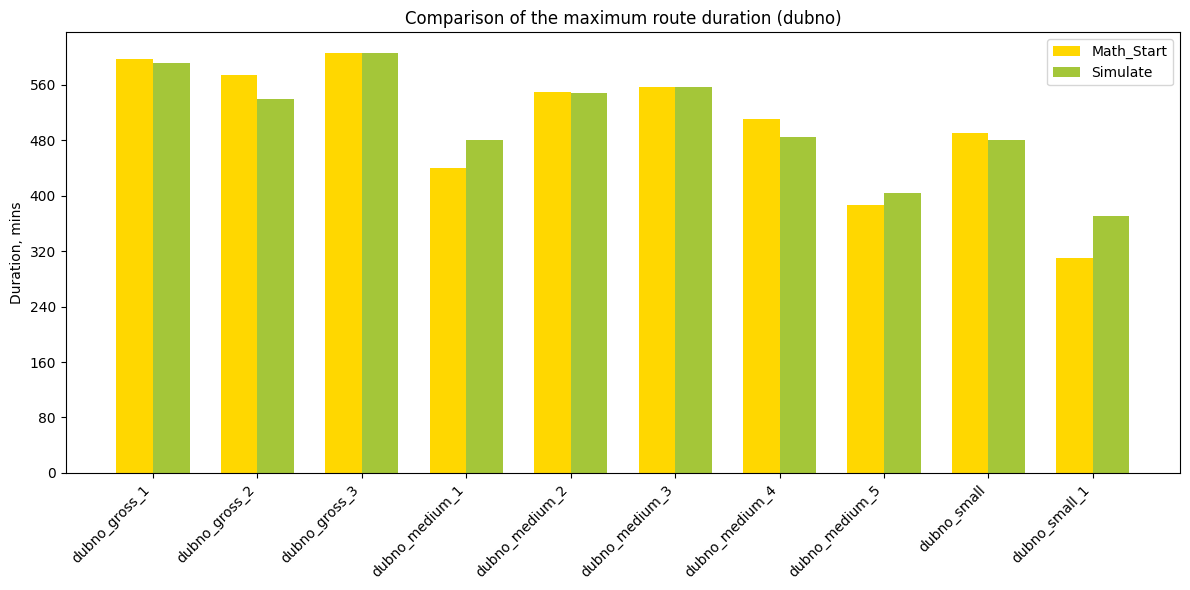

In [45]:
plot_metric_by_city(
    dataset_compare=smaller_results,
    metric_math="max_duration_Math_Start",
    metric_sim="max_duration_Simulate",
    ylabel="Duration, mins",
    title_prefix="Comparison of the maximum route duration",
    city="ternopil"
)

plot_metric_by_city(
    dataset_compare=smaller_results,
    metric_math="max_duration_Math_Start",
    metric_sim="max_duration_Simulate",
    ylabel="Duration, mins",
    title_prefix="Comparison of the maximum route duration",
    city="dubno"
)